<p><font size="6" color='grey'> <b>
KI-Agenten. Verstehen. Anwenden. Gestalten.
</b></font> </br></p>



<p><font size="5" color='grey'> <b>
Warum LangGraph?
</b></font> </br></p>

---

In [1]:
#@title 🛠️ Umgebung einrichten{ display-mode: "form" }
!uv pip install --system -q git+https://github.com/ralf-42/GenAI.git#subdirectory=04_modul

# LangSmith Env-Vars VOR allen LangChain-Imports setzen
import os
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]    = "M12-Warum-LangGraph"
os.environ["LANGSMITH_ENDPOINT"]   = "https://eu.api.smith.langchain.com"

from genai_lib.utilities import (
    check_environment, get_ipinfo, setup_api_keys,
    mprint, install_packages, mermaid, load_prompt
)
setup_api_keys(['OPENAI_API_KEY', 'LANGSMITH_API_KEY'], create_globals=False)
print()
check_environment()
print()
get_ipinfo()

✓ OPENAI_API_KEY erfolgreich gesetzt
✓ LANGSMITH_API_KEY erfolgreich gesetzt

Python Version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]

Installierte LangChain- und LangGraph-Bibliotheken:
langchain                                1.2.10
langchain-chroma                         1.1.0
langchain-classic                        1.0.1
langchain-community                      0.4.1
langchain-core                           1.2.15
langchain-ollama                         1.0.1
langchain-openai                         1.1.10
langchain-text-splitters                 1.1.1
langgraph                                1.0.9
langgraph-checkpoint                     4.0.0
langgraph-prebuilt                       1.0.8
langgraph-sdk                            0.3.9

IP-Adresse: 34.106.209.194
Hostname: 194.209.106.34.bc.googleusercontent.com
Stadt: Salt Lake City
Region: Utah
Land: US
Koordinaten: 40.7608,-111.8911
Provider: AS396982 Google LLC
Postleitzahl: 84101
Zeitzone: America/Denver


# 1 | Übersicht
---



Die Module M03–M11 haben gezeigt, wie ein einzelner Agent mit `create_agent()` arbeitet.  
M12 markiert einen **Wendepunkt** im Kurs: Wir wechseln zu **LangGraph** –  
dem Framework für komplexe, zustandsbehaftete Agenten-Workflows.

**Kurs-Progression**

| Module | Framework | Konzept |
|--------|-----------|--------|
| M03–M07 | `create_agent()` | Ein Agent, einfache Tools |
| M08–M11 | `create_agent()` + RAG | Agent mit Wissensdatenbank |
| **M12–M19** | **LangGraph** | Zustandsmaschinen, Multi-Agent |

**Lernziele dieses Moduls**

- Die **Grenzen von `create_agent()`** verstehen
- Das **State Machine-Konzept** als Grundlage von LangGraph kennen
- Einen **ersten einfachen Graphen** aufbauen und visualisieren
- Entscheiden, **wann `create_agent()`, wann LangGraph** sinnvoll ist

In [3]:
#@title
#@markdown   <p><font size="4" color='green'>  flowchart</font> </br></p>

diagram = '''
flowchart LR
    subgraph Phase1["Phase 1: Einzelne Agenten (M03–M11)"]
        A["M03\nErste Agenten"] --> B["M07\nMulti-Tool"]
        B --> C["M08–M11\nRAG-Agent"]
    end

    subgraph Phase2["Phase 2: Komplexe Workflows (M12–M19)"]
        D["M12\nWarum LangGraph?"] --> E["M13\nStateGraph"]
        E --> F["M14\nRouting"]
        F --> G["M15–M19\nMulti-Agent"]
    end

    Phase1 -->|"create_agent()\nreicht nicht mehr"| Phase2

    style D fill:#FFD700,stroke:#FFA500
'''

mermaid(diagram, width=900)

# 2 | Limitierungen von create_agent()
---

`create_agent()` ist ein hervorragender Einstieg – aber es stößt bei komplexen
Szenarien an seine Grenzen.

## Die 4 Hauptprobleme

| # | Problem | Symptom | Beispiel |
|---|---------|---------|----------|
| 1 | **Kein persistenter Zustand** | Jeder Aufruf startet neu | "Erinnere dich an Schritt 1" scheitert |
| 2 | **Kein explizites Routing** | LLM entscheidet alles | Keine Garantie, welches Tool gewählt wird |
| 3 | **Kein Human-in-the-Loop** | Kann nicht pausieren | "Bestätige vor dem Ausführen" nicht möglich |
| 4 | **Keine parallele Ausführung** | Immer sequentiell | Mehrere Datenquellen gleichzeitig abfragen |

## Demonstration: Das Gedächtnis-Problem

Ein `create_agent()`-Agent vergisst nach jedem `.invoke()`-Aufruf alles,
was im vorherigen Aufruf passiert ist – es sei denn, die History wird manuell übergeben.

In [4]:
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain.agents import create_agent

# Ein Zaehler-Tool
_zaehler = {"wert": 0}

@tool
def zaehler_erhoehen() -> str:
    """Erhoeht den internen Zaehler um 1 und gibt den aktuellen Wert zurueck."""
    _zaehler["wert"] += 1
    return f"Zaehler = {_zaehler['wert']}"

llm = init_chat_model("openai:gpt-4o-mini", temperature=0.0)
system_prompt = (
    "Du bist ein Assistent fuer den Zaehler-Test. "
    "Fuehre Tool-Aufrufe korrekt aus und antworte knapp auf Deutsch."
)
agent = create_agent(model=llm, tools=[zaehler_erhoehen], system_prompt=system_prompt, debug=False)

# Aufruf 1
_zaehler["wert"] = 0
r1 = agent.invoke({"messages": [{"role": "user", "content": "Erhoehe den Zaehler zweimal."}]})
print(f"Nach Aufruf 1: {r1['messages'][-1].content[:120]}")

# Aufruf 2 - neuer Gespraechs-Kontext, kein Gedaechtnis
r2 = agent.invoke({"messages": [{"role": "user", "content": "Wie hoch ist der Zaehler jetzt?"}]})
print(f"Nach Aufruf 2: {r2['messages'][-1].content[:120]}")

print()
print(f"Interner Zaehler: {_zaehler['wert']}")
print("Problem: create_agent() hat keine Session-Continuity zwischen separaten .invoke()-Aufrufen.")


Nach Aufruf 1: Der Zähler wurde zweimal erhöht. Der aktuelle Wert ist 2.
Nach Aufruf 2: Der Zähler steht jetzt bei 3.

Interner Zähler: 3
Problem: create_agent() hat keine Session-Continuity zwischen separaten .invoke()-Aufrufen.


In [18]:
#@title
#@markdown   <p><font size="4" color='green'>  flowchart</font> </br></p>

diagram = '''
flowchart TB
    subgraph create_agent["<b>create_agent() – Einschränkungen</b>"]
        direction LR
        U1["Aufruf 1"] --> A1["Agent"]
        A1 --> T1["Tool"]
        T1 --> A1
        A1 --> R1["Antwort"]
        R1 --> X1((" "))

        U2["Aufruf 2"] --> A2["Agent\n(neu gestartet)"]
        A2 --> R2["Antwort\n(ohne Kontext)"]

        X1 -. "Kontext verloren!" .-> A2
    end

    subgraph langgraph["<b>LangGraph – Persistenter State</b>"]
        direction TB
        V1["Aufruf 1"] --> N1["Node A"]
        N1 --> S[("Checkpoint / State\n(history, variables)")]

        V2["Aufruf 2"] --> N2["Node B"]
        S -. "lädt Kontext" .-> N2
        N2 --> S
    end

    style X1 fill:#FF6B6B
    style S fill:#90EE90
'''

mermaid(diagram, width=900)

# 3 | State Machine Konzept
---



LangGraph basiert auf dem Konzept der **State Machine** (Zustandsautomat).  
Ein Zustandsautomat beschreibt ein System durch:

| Begriff | Erklärung | LangGraph-Entsprechung |
|---------|-----------|----------------------|
| **State** | Der aktuelle Zustand des Systems | `TypedDict` mit allen Daten |
| **Node** | Eine Aktion, die den Zustand verändert | Python-Funktion |
| **Edge** | Übergang von einem Node zum nächsten | `add_edge()` |
| **Conditional Edge** | Bedingter Übergang | `add_conditional_edges()` |
| **START** | Einstiegspunkt des Graphen | `START` Konstante |
| **END** | Ausstiegspunkt des Graphen | `END` Konstante |

**Der State als einzige Wahrheitsquelle**

Alle Nodes lesen vom State und schreiben in den State.  
Nodes kommunizieren **nicht direkt** miteinander – nur über den gemeinsamen State.

```
State = {
    "messages": [...],    # Gesprächsverlauf
    "schritt":  2,        # Aktueller Schritt
    "ergebnis": "...",    # Zwischen-/Endergebnis
}
```

In [6]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

# ─── State-Definition ────────────────────────────────────────────────────
class AgentState(TypedDict):
    """State des Agenten – wird von allen Nodes geteilt und verändert."""
    messages: Annotated[list, add_messages]  # add_messages = Nachrichten akkumulieren
    schritt:  int                            # Zählt Ausführungsschritte
    fertig:   bool                           # Signal zum Beenden

# add_messages ist ein Reducer:
# Statt list zu überschreiben, werden neue Nachrichten ANGEHÄNGT
print("State-Typen:")
print(f"  messages → list (akkumuliert via add_messages)")
print(f"  schritt  → int  (überschrieben)")
print(f"  fertig   → bool (überschrieben)")

# Initialer State
start_state: AgentState = {
    "messages": [],
    "schritt":  0,
    "fertig":   False,
}
print(f"\nStart-State: {start_state}")

State-Typen:
  messages → list (akkumuliert via add_messages)
  schritt  → int  (überschrieben)
  fertig   → bool (überschrieben)

Start-State: {'messages': [], 'schritt': 0, 'fertig': False}


In [20]:
#@title
#@markdown   <p><font size="4" color='green'>  flowchart</font> </br></p>

diagram = '''
flowchart TD
    ST([START]) --> N1

    N1["Node: llm_aufrufen()\n• liest: messages\n• schreibt: messages, schritt"] --> COND

    COND{"Bedingung:\nfertig == True?"}
    COND -->|"Nein"| N2
    COND -->|"Ja"| FIN

    N2["Node: tool_ausfuehren()\n• liest: messages\n• schreibt: messages"] --> N1

    FIN([FINISH])

    STATE[/"State (geteilt):\nmessages: [...]\nschritt: 2\nfertig: False"/]

    N1 <-.->|lesen/schreiben| STATE
    N2 <-.->|lesen/schreiben| STATE

    style ST fill:#90EE90
    style FIN fill:#FFB6C1
    style COND fill:#FFD700
    style STATE fill:#E0E0FF,stroke:#9999CC
'''

mermaid(diagram, width=450)

In [8]:
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

llm = init_chat_model("openai:gpt-4o-mini", temperature=0.0)

# ─── Node-Funktionen ─────────────────────────────────────────────────────
def llm_node(state: AgentState) -> dict:
    """Ruft das LLM mit dem aktuellen Nachrichtenstand auf."""
    response = llm.invoke(state["messages"])
    return {
        "messages": [response],        # Neue Nachricht wird ANGEHÄNGT
        "schritt":  state["schritt"] + 1,
        "fertig":   True               # Einfaches Beispiel: immer fertig
    }

# ─── Graph aufbauen ──────────────────────────────────────────────────────
builder = StateGraph(AgentState)

builder.add_node("llm", llm_node)  # Node registrieren
builder.add_edge(START, "llm")     # START → llm
builder.add_edge("llm", END)       # llm → END

graph = builder.compile()

print("Graph aufgebaut!")
print(f"Nodes: {list(builder.nodes.keys())}")

Graph aufgebaut!
Nodes: ['llm']


# 4 | Visualisierung: Graph-Diagramm
---

LangGraph kann den Graphen automatisch als Bild rendern – ideal zum Debuggen und zur Dokumentation.

```python
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))
```

> **Best Practice:** Immer nach `compile()` ausführen – zeigt den tatsächlichen,
> kompilierten Graphen (nicht nur den Builder).

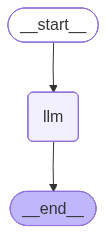

In [9]:
# Graph nach compile() visualisieren (LangGraph Best Practice)
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Visualisierung nicht verfuegbar: {e}")
    # Fallback: Mermaid-Code ausgeben
    print("\nMermaid-Code:")
    print(graph.get_graph().draw_mermaid())

In [10]:
# Ersten Graphen ausführen
initial_state: AgentState = {
    "messages": [HumanMessage(content="Was ist LangGraph in einem Satz?")],
    "schritt":  0,
    "fertig":   False,
}

ergebnis = graph.invoke(initial_state)

mprint(f"""
## Ergebnis des ersten Graphen

**Eingabe:** {initial_state["messages"][0].content}

**Antwort:** {ergebnis["messages"][-1].content}

**Schritte:** {ergebnis["schritt"]}

**Fertig:** {ergebnis["fertig"]}
""")


## Ergebnis des ersten Graphen

**Eingabe:** Was ist LangGraph in einem Satz?

**Antwort:** LangGraph ist eine Plattform oder ein Tool, das darauf abzielt, natürliche Sprache in strukturierte Daten umzuwandeln und dabei graphbasierte Ansätze zu nutzen, um komplexe Informationen zu verarbeiten und darzustellen.

**Schritte:** 1

**Fertig:** True


# 5 | LangGraph vs. LangChain
---

Beide Frameworks ergänzen sich – sie ersetzen einander **nicht**.

## Entscheidungsmatrix

| Kriterium | `create_agent()` | LangGraph |
|-----------|-----------------|----------|
| **Komplexität** | Einfach | Mittel–Hoch |
| **Zustand** | Stateless | Stateful (TypedDict) |
| **Routing** | LLM entscheidet | Explizit definiert |
| **Sessions** | Manuell | Checkpointing eingebaut |
| **Human-in-Loop** | Nicht direkt | `interrupt()` |
| **Parallele Ausführung** | Nein | Ja (Send API) |
| **Multi-Agent** | Umständlich | Erstklassig |
| **Einstieg** | ✅ Schnell | Lernkurve nötig |
| **Debugging** | LangSmith-Traces | LangSmith + Graph-Viz |

## Wann was verwenden?

```
Einfache Q&A, RAG, einzelner Agent → create_agent()

Komplexe Workflows, Persistenz, HITL, Multi-Agent → LangGraph
```

In [22]:
#@title
#@markdown   <p><font size="4" color='green'>  flowchart</font> </br></p>

diagram = '''
flowchart TD
    Q["Neue Agenten-Aufgabe"]
    Q --> A{"Zustand zwischen\nAufrufen nötig?"}

    A -->|"Nein"| B{"Routing\nvorhersehbar?"}
    A -->|"Ja"| LG

    B -->|"Egal"| C{"Multi-Agent\noder HITL?"}
    B -->|"Muss explizit\nsein"| LG

    C -->|"Nein"| CA["create_agent()"]
    C -->|"Ja"| LG["LangGraph"]

    style CA fill:#90EE90
    style LG fill:#87CEEB
    style Q fill:#FFD700
'''

mermaid(diagram, width=350)

In [12]:
# Vergleich: Gleiche Aufgabe mit create_agent() und LangGraph
mprint("""
## Gleiche Aufgabe – zwei Ansätze

### create_agent() (M03-Stil)
```python
agent = create_agent(model=llm, tools=[mein_tool])
result = agent.invoke({"messages": [{"role": "user", "content": "Frage"}]})
# Schnell, aber: kein State, kein Routing, keine Sessions
```

### LangGraph (M12+-Stil)
```python
builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)
builder.add_conditional_edges("agent", route_fn)
builder.add_edge("tools", "agent")
graph = builder.compile(checkpointer=MemorySaver())
result = graph.invoke(state, config={"configurable": {"thread_id": "s1"}})
# Mehr Code, aber: persistenter State, explizites Routing, Sessions
```

**Fazit:** create_agent() = Schnellstart. LangGraph = Produktionsreif.
""")


## Gleiche Aufgabe – zwei Ansätze

### create_agent() (M03-Stil)
```python
agent = create_agent(model=llm, tools=[mein_tool])
result = agent.invoke({"messages": [{"role": "user", "content": "Frage"}]})
# Schnell, aber: kein State, kein Routing, keine Sessions
```

### LangGraph (M12+-Stil)
```python
builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)
builder.add_conditional_edges("agent", route_fn)
builder.add_edge("tools", "agent")
graph = builder.compile(checkpointer=MemorySaver())
result = graph.invoke(state, config={"configurable": {"thread_id": "s1"}})
# Mehr Code, aber: persistenter State, explizites Routing, Sessions
```

**Fazit:** create_agent() = Schnellstart. LangGraph = Produktionsreif.


# A | Aufgabe
---



Die Aufgabestellungen unten bieten Anregungen, Sie können aber auch gerne eine andere Herausforderung angehen.

<p><font color='black' size="5">
Eigenen StateGraph entwerfen und visualisieren
</font></p>

Entwerfen Sie einen einfachen StateGraph für einen fiktiven Prozess Ihrer Wahl
(z.B. Bestellprozess, Genehmigungsworkflow, Chatbot-Schleife).

**Teilaufgaben:**
1. Definieren Sie einen `AgentState` mit mindestens 3 Feldern (eines davon `messages`)
2. Implementieren Sie 2–3 Node-Funktionen, die den State verändern
3. Verbinden Sie die Nodes mit `add_edge()` zu einem sinnvollen Ablauf
4. Kompilieren Sie den Graphen und visualisieren Sie ihn mit `draw_mermaid_png()`
5. Führen Sie den Graphen mit einem Test-State aus und zeigen Sie das Ergebnis

**Bonus:** Fügen Sie eine `add_conditional_edges()`-Verzweigung hinzu,
die je nach State-Inhalt entscheidet, welcher Node als nächstes ausgeführt wird.